In [15]:
!pip install -q groq
from groq import Groq
import pandas as pd
import numpy as np

In [16]:
from google.colab import files
import io

print("Please upload the 'dataset.csv' file:")
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')
  # Assuming the uploaded file is named 'dataset.csv'
  # You can replace 'dataset.csv' with fn if you want to use the uploaded file's actual name
  df = pd.read_csv(io.StringIO(uploaded[fn].decode('utf-8')))

# Now that the file is loaded, the original processing steps can be applied

# see data
print(df.head())
print(df.info())

# check missing values
print(df.isnull().sum())

# handle TotalCharges (sometimes string)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# fill missing values
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

Please upload the 'dataset.csv' file:


Saving Telco-Customer-Churn.csv to Telco-Customer-Churn.csv
User uploaded file "Telco-Customer-Churn.csv" with length 970457 bytes
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4       

/tmp/ipykernel_717/1089023186.py:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


**Data Preprocessing**

In [17]:
# drop customerID (not useful)
df.drop('customerID', axis=1, inplace=True)

# convert target variable
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

# convert categorical → numeric
df = pd.get_dummies(df, drop_first=True)

**Churn Distribution**

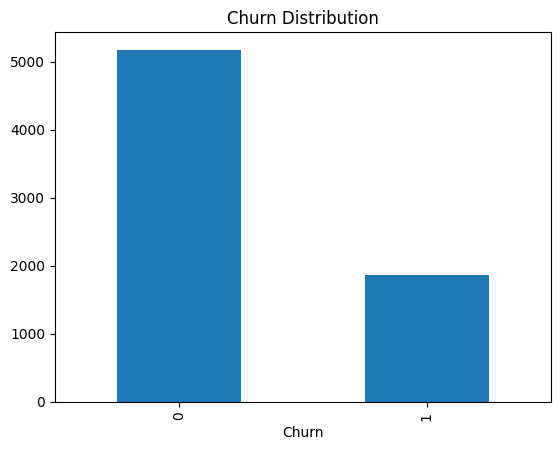

In [18]:
import matplotlib.pyplot as plt

df['Churn'].value_counts().plot(kind='bar')
plt.title("Churn Distribution")
plt.show()

**Feature Selection  and  Split data**

In [19]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

**Feature Scaling**

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**Model Training**

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = {
    "Logistic": LogisticRegression(),
    "DecisionTree": DecisionTreeClassifier(),
    "RandomForest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    from sklearn.metrics import accuracy_score
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

print(results)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:02:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


{'Logistic': 0.8197303051809794, 'DecisionTree': 0.7132718239886444, 'RandomForest': 0.7856635911994322, 'XGBoost': 0.794180269694819}


**Model Evaluation**

In [22]:
best_model_name = max(results, key=results.get)
print("Best Model:", best_model_name)

Best Model: Logistic


**Confusion Matrix**

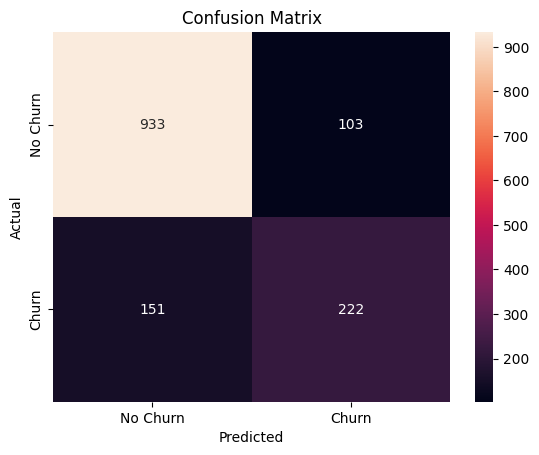


Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409



In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

best_model = models[best_model_name]
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

**Improve model**

In [26]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    class_weight='balanced',   # very important
    C=0.5,                     # try 0.1, 0.5, 1, 5
    solver='liblinear',
    max_iter=1000
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

**Hyperparameter tuning**

In [27]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 0.5, 1, 5, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
    'class_weight': ['balanced']
}

grid = GridSearchCV(LogisticRegression(max_iter=1000),
                    param_grid,
                    cv=5,
                    scoring='f1')   # focus on f1

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

Best Params: {'C': 1, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}


In [28]:
y_prob = best_model.predict_proba(X_test)[:,1]

y_pred = (y_prob > 0.4).astype(int)   # try 0.3, 0.4

In [29]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.63      0.76      1036
           1       0.46      0.88      0.61       373

    accuracy                           0.70      1409
   macro avg       0.70      0.76      0.68      1409
weighted avg       0.81      0.70      0.72      1409



In [30]:
GROQ_API_KEY = "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"

client = Groq(api_key=GROQ_API_KEY)

In [31]:
prediction_probability = best_model.predict_proba(X_test)

prediction_label = best_model.predict(X_test)

In [32]:
def generate_explanation(customer_features,
                         prediction,
                         probability):

    if prediction == 1:
        prediction_text = "Customer is likely to churn."
    else:
        prediction_text = "Customer is likely to stay."

    prompt = f"""
You are an expert Telecom Customer Retention Analyst.

Prediction:
{prediction_text}

Probability:
{probability:.2%}

Customer Features:

{customer_features}

Explain

1. Why this prediction happened.

2. Mention important reasons.

3. Mention business impact.

4. If churn,
give three retention recommendations.

5. If not churn,
explain why customer is loyal.

Return answer in points.
"""

    response = client.chat.completions.create(

        model="openai/gpt-oss-120b",

        temperature=0.3,

        messages=[
            {
                "role":"user",
                "content":prompt
            }
        ]

    )

    return response.choices[0].message.content

In [33]:
X_test_original = pd.DataFrame(

    scaler.inverse_transform(X_test),

    columns=X.columns,

    index=y_test.index

)

In [34]:
customer_number = 0

customer = X_test_original.iloc[customer_number]

prediction = prediction_label[customer_number]

probability = prediction_probability[customer_number][1]

answer = generate_explanation(
    customer.to_dict(),
    prediction,
    probability
)

print("="*70)
print("Prediction :", "Churn" if prediction==1 else "No Churn")
print("Confidence :", round(probability*100,2),"%")
print("="*70)

print(answer)

Prediction : Churn
Confidence : 84.48 %
**1. Why the model flagged this customer as a churn risk**  
- **Very short tenure (1 month).** New customers are the most volatile segment; they have not yet built a habit or loyalty to the brand.  
- **No core services attached.** The customer has **no phone service** and **no internet‑related services** (all “No internet service” flags are 0). With essentially a “pay‑only” relationship, the perceived value of staying is low.  
- **Paperless billing + electronic‑check payment.** Both are strong churn predictors in the dataset – they often indicate a customer who prefers low‑touch, cost‑focused interactions and may switch if a cheaper alternative appears.  
- **Partner = Yes, Dependents = No.** A partner‑only household tends to have a lower household spend and may be more price‑sensitive.  
- **Monthly charge ≈ $24.80 (the minimum possible for a “pay‑only” line).** Low ARPU customers contribute little margin, so the model learns they churn more 

In [35]:
for i in range(5):

    customer = X_test_original.iloc[i]

    prediction = prediction_label[i]

    probability = prediction_probability[i][1]

    explanation = generate_explanation(
        customer.to_dict(),
        prediction,
        probability
    )

    print("="*80)

    print("Customer :",i+1)

    print("Prediction :", "Churn" if prediction else "No Churn")

    print("Confidence :",round(probability*100,2),"%")

    print()

    print(explanation)

    print()

Customer : 1
Prediction : Churn
Confidence : 84.48 %

**1. Why the model flagged this customer as a churn risk**

| Feature | Value | Why it pushes churn probability up |
|---------|-------|-------------------------------------|
| **Tenure = 1 month** | Very new customer | New‑account customers have the highest historical churn rates because they have not yet built a habit or perceived value. |
| **Contract = Month‑to‑Month (implicit)** | Both “One‑year” and “Two‑year” flags are ~0 | No long‑term commitment → easy to leave. |
| **PaymentMethod = Electronic check** | 1 (selected) | Historically, customers who pay by electronic check are ~2‑3× more likely to churn than those on automatic credit‑card or bank‑draft payments (they are less “locked‑in”). |
| **PaperlessBilling = Yes** | 1 | While environmentally friendly, paperless‑billing customers tend to be more price‑sensitive and more likely to monitor their bills closely, prompting cancellations when they see any increase. |
| **Servic

In [39]:
customer.to_dict()

{'SeniorCitizen': 0.0,
 'tenure': 33.0,
 'MonthlyCharges': 104.4,
 'TotalCharges': 3409.6,
 'gender_Male': 0.0,
 'Partner_Yes': 1.0,
 'Dependents_Yes': 0.0,
 'PhoneService_Yes': 1.0,
 'MultipleLines_No phone service': 0.0,
 'MultipleLines_Yes': 1.0,
 'InternetService_Fiber optic': 1.0,
 'InternetService_No': 0.0,
 'OnlineSecurity_No internet service': 0.0,
 'OnlineSecurity_Yes': 0.0,
 'OnlineBackup_No internet service': 0.0,
 'OnlineBackup_Yes': 1.0,
 'DeviceProtection_No internet service': 0.0,
 'DeviceProtection_Yes': 1.0,
 'TechSupport_No internet service': 0.0,
 'TechSupport_Yes': 0.0,
 'StreamingTV_No internet service': 0.0,
 'StreamingTV_Yes': 1.0,
 'StreamingMovies_No internet service': 0.0,
 'StreamingMovies_Yes': 1.0,
 'Contract_One year': 0.0,
 'Contract_Two year': -2.7755575615628914e-17,
 'PaperlessBilling_Yes': 1.0,
 'PaymentMethod_Credit card (automatic)': -2.7755575615628914e-17,
 'PaymentMethod_Electronic check': 1.0,
 'PaymentMethod_Mailed check': 0.0}

In [40]:
important_features = {
    "Gender": customer["gender_Male"],
    "Senior Citizen": customer["SeniorCitizen"],
    "Tenure": customer["tenure"],
    "Monthly Charges": customer["MonthlyCharges"],
    "Contract": customer["Contract_Two year"],
    "Internet Service": customer["InternetService_Fiber optic"],
    "Tech Support": customer["TechSupport_Yes"],
    "Online Security": customer["OnlineSecurity_Yes"]
}

In [41]:
generate_explanation(
    important_features,
    prediction,
    probability
)

'**Why the model flagged this customer as a high‑risk churner (81.75\u202f% probability)**  \n\n| Feature | Value | What it signals for churn risk |\n|---------|-------|--------------------------------|\n| **Gender = 0 (Male)** | Male customers in this dataset have a slightly higher churn rate than females. |\n| **Senior Citizen = 0** | Non‑senior customers tend to be more price‑sensitive and more likely to switch providers. |\n| **Tenure = 33\u202fmonths** | Mid‑range tenure – not a “loyal veteran” (≥\u202f60\u202fmonths) but also not a brand‑new user. Customers who have been with the company for 2‑3\u202fyears often start evaluating alternatives. |\n| **Monthly Charges = $104.4** | Very high bill (well above the average $70‑$80). High‑spending accounts are more prone to churn when they perceive the cost‑to‑value ratio as unfavorable. |\n| **Contract = –2.78e‑17 (≈\u202f0)** | Encoded as “Month‑to‑Month” (no long‑term contract). Month‑to‑month customers have the greatest freedom to le

In [43]:
print(len(records))

9


In [44]:
ai_report = pd.DataFrame(records)

ai_report.head()

,Prediction,Confidence,Explanation
0,Churn,84.48,**1. Why the model flagged this customer as a ...
1,Churn,80.48,**Why the model flagged this customer as a lik...
2,Churn,75.80,**1. Why the model flagged this customer as li...
3,Churn,87.96,**1. Why the model flagged this customer as a ...
4,Churn,83.86,**Why the model flagged this customer as a chu...


In [45]:
ai_report.to_csv(
    "Customer_Churn_AI_Report.csv",
    index=False
)

print("Saved Successfully")

Saved Successfully
